### Setup


In [1]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

In [2]:
import numpy as np
import pandas as pd
import bambi as bmb
import arviz as az

from prettytable import PrettyTable
from sklearn.metrics import r2_score 

from src.stat_utils import *
from src.anl_utils import load_data, get_session_data

### Load and prepare data

In [133]:
sim_results_folder = '../results/simulation'
data_folder = '../data'
sync_at_file = os.path.join(sim_results_folder, 'first_session_arnold_tongues.npy')
hires_files = os.path.join(sim_results_folder, 'highres_arnold_tongues.npy')
effective_fr_file = os.path.join(sim_results_folder, 'first_session_effective_firing_rates.npy')
emp_at_file = os.path.join(data_folder, 'Experiment.csv')

In [ ]:
# Load the simulations results and the empirical data
sync_results = np.load(sync_at_file)
#sync_results = np.load(hires_files)[-1,:,::7,::7]
sync_results_vector = sync_results.mean(axis=0).flatten()


effective_results = np.load(effective_fr_file)
effective_vector = effective_results.mean(axis=0).flatten()
reference = effective_results[:,:,-1]
delta_results = effective_results - np.expand_dims(reference, 2)
delta_vector = delta_results.mean(axis=0).flatten()



data = load_data(emp_at_file)
# Get the data for the first session
data = get_session_data(data, 1)


# Map synchrony values to each condition in DataFrame
data['Synchrony'] = data['Condition'].apply(lambda x: sync_results_vector[x-1])
data['EffectiveFiring'] = data['Condition'].apply(lambda x: effective_vector[x-1])
data['DeltaFiring'] = data['Condition'].apply(lambda x: delta_vector[x-1])

data = data[data['ContrastHeterogeneity'] != 1].copy()

data = zscore_data(data, ['ContrastHeterogeneity', 'GridCoarseness', 'Synchrony', 'EffectiveFiring', 'DeltaFiring'])

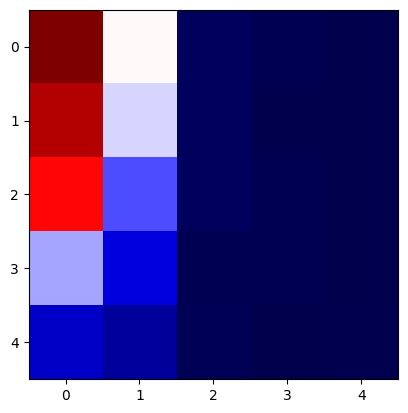

In [145]:
plt.imshow(sync_results.mean(axis=0),cmap = 'seismic')

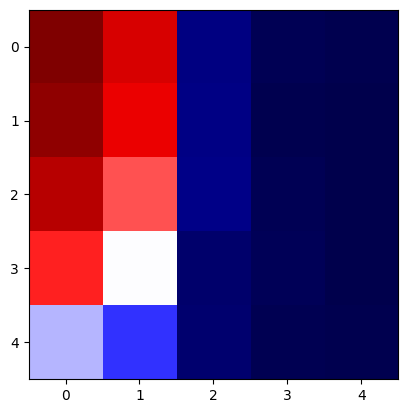

In [143]:
plt.imshow(sync_results.mean(axis=0),cmap = 'seismic')

### Define statistical models

In [147]:
# Features-only hierarchical logistic regression
model_features = bmb.Model(
    "Correct ~ 1 + ContrastHeterogeneity * GridCoarseness + (1 + ContrastHeterogeneity * GridCoarseness|SubjectID)",
    data=data,
    family="bernoulli"
)

# Model synchrony (mechanism)
model_sync = bmb.Model(
    "Correct ~ 1 + Synchrony + (1 + Synchrony | SubjectID)",
    data=data,
    family="bernoulli"
)

model_effective = bmb.Model(
    "Correct ~ 1 + EffectiveFiring + (1 + EffectiveFiring | SubjectID)",
    data=data,
    family="bernoulli"
)

model_delta = bmb.Model(
    "Correct ~ 1 + DeltaFiring + (1 + DeltaFiring | SubjectID)",
    data=data,
    family="bernoulli"
)

# Full model (features + mechanism)
model_full = bmb.Model(
    "Correct ~ 1 + Synchrony + ContrastHeterogeneity * GridCoarseness + (1 + Synchrony + ContrastHeterogeneity * GridCoarseness|SubjectID)",
    data=data,
    family="bernoulli"
)

# Model V1 (Synchrony in V1 model as function of features)
model_v1 = bmb.Model(
    "Synchrony ~ 1 + ContrastHeterogeneity * GridCoarseness + (1 + ContrastHeterogeneity * GridCoarseness | SubjectID)",
    data=data,
    family="gaussian"
)

Are the factors that determine synchrony among coupled oscillators (frequency detuning and coupling strength) predictive of human ability to segregate a rectangular figure from its background in texture stimuli? 

In [113]:
idata_features = model_features.fit(
    draws=2000, tune=2000, target_accept=0.95,
    idata_kwargs={"log_likelihood": True}, progressbar=False
)

Modeling the probability that Correct==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, ContrastHeterogeneity, GridCoarseness, ContrastHeterogeneity:GridCoarseness, 1|SubjectID_sigma, 1|SubjectID_offset, ContrastHeterogeneity|SubjectID_sigma, ContrastHeterogeneity|SubjectID_offset, GridCoarseness|SubjectID_sigma, GridCoarseness|SubjectID_offset, ContrastHeterogeneity:GridCoarseness|SubjectID_sigma, ContrastHeterogeneity:GridCoarseness|SubjectID_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 144 seconds.


In [114]:
predictors = ["ContrastHeterogeneity", "GridCoarseness", "ContrastHeterogeneity:GridCoarseness"]
directions = ['less', 'less', 'greater']

posterior = posterior_table(idata_features, predictors, directions)

odds_ratios = OR_table(idata_features, predictors)

print("One-sided posterior probabilities:")
print(posterior)
print("\nOdds ratios:")
print(odds_ratios)

az.summary(idata_features, var_names=predictors, hdi_prob=0.95)

One-sided posterior probabilities:
+--------------------------------------+-----------+-------+
|              Predictor               | direction |   P   |
+--------------------------------------+-----------+-------+
|        ContrastHeterogeneity         |    less   | 0.999 |
|            GridCoarseness            |    less   | 0.999 |
| ContrastHeterogeneity:GridCoarseness |  greater  | 0.995 |
+--------------------------------------+-----------+-------+

Odds ratios:
+--------------------------------------+-------+--------------+---------------+
|              Predictor               |  Mean | Lower (2.5%) | Upper (97.5%) |
+--------------------------------------+-------+--------------+---------------+
|        ContrastHeterogeneity         | 0.601 |    0.460     |     0.770     |
|            GridCoarseness            | 0.705 |    0.590     |     0.829     |
| ContrastHeterogeneity:GridCoarseness | 1.270 |    1.092     |     1.473     |
+--------------------------------------+----

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ContrastHeterogeneity,-0.517,0.129,-0.765,-0.254,0.002,0.002,2938.0,4212.0,1.0
GridCoarseness,-0.353,0.084,-0.531,-0.192,0.001,0.001,4226.0,4736.0,1.0
ContrastHeterogeneity:GridCoarseness,0.236,0.076,0.091,0.389,0.001,0.001,4126.0,4188.0,1.0


Does the synchronization behavior of a biophysical model of V1 predict human ability to segregate a rectangular figure from its background in texture stimuli?

In [148]:
idata_sync = model_sync.fit(
    draws=2000, tune=2000, target_accept=0.95,
    idata_kwargs={"log_likelihood": True}, progressbar=False
)

Modeling the probability that Correct==1
Initializing NUTS using jitter+adapt_diag...
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Synchrony, 1|SubjectID_sigma, 1|SubjectID_offset, Synchrony|SubjectID_sigma, Synchrony|SubjectID_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 99 seconds.


In [149]:
predictors = ["Synchrony"]
directions = ['greater']

posterior = posterior_table(idata_sync, predictors, directions)
odds_ratios = OR_table(idata_sync, predictors)

print("One-sided posterior probabilities:")
print(posterior)
print("\nOdds ratios:")
print(odds_ratios)

az.summary(idata_sync, var_names=predictors, hdi_prob=0.95)

One-sided posterior probabilities:
+-----------+-----------+-------+
| Predictor | direction |   P   |
+-----------+-----------+-------+
| Synchrony |  greater  | 1.000 |
+-----------+-----------+-------+

Odds ratios:
+-----------+-------+--------------+---------------+
| Predictor |  Mean | Lower (2.5%) | Upper (97.5%) |
+-----------+-------+--------------+---------------+
| Synchrony | 3.717 |    2.564     |     5.160     |
+-----------+-------+--------------+---------------+


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Synchrony,1.298,0.176,0.97,1.666,0.003,0.003,3266.0,3719.0,1.0


In [129]:
idata_effective = model_effective.fit(
    draws=2000, tune=2000, target_accept=0.95,
    idata_kwargs={"log_likelihood": True}, progressbar=False
)

Modeling the probability that Correct==1
Initializing NUTS using jitter+adapt_diag...
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, EffectiveFiring, 1|SubjectID_sigma, 1|SubjectID_offset, EffectiveFiring|SubjectID_sigma, EffectiveFiring|SubjectID_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 51 seconds.


In [130]:
predictors = ["EffectiveFiring"]
directions = ['less']

posterior = posterior_table(idata_effective, predictors, directions)
odds_ratios = OR_table(idata_effective, predictors)

print("One-sided posterior probabilities:")
print(posterior)
print("\nOdds ratios:")
print(odds_ratios)

az.summary(idata_effective, var_names=predictors, hdi_prob=0.95)

One-sided posterior probabilities:
+-----------------+-----------+-------+
|    Predictor    | direction |   P   |
+-----------------+-----------+-------+
| EffectiveFiring |    less   | 0.178 |
+-----------------+-----------+-------+

Odds ratios:
+-----------------+-------+--------------+---------------+
|    Predictor    |  Mean | Lower (2.5%) | Upper (97.5%) |
+-----------------+-------+--------------+---------------+
| EffectiveFiring | 1.063 |    0.917     |     1.230     |
+-----------------+-------+--------------+---------------+


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
EffectiveFiring,0.059,0.072,-0.091,0.202,0.001,0.001,3348.0,3333.0,1.0


In [131]:
idata_delta = model_delta.fit(
    draws=2000, tune=2000, target_accept=0.95,
    idata_kwargs={"log_likelihood": True}, progressbar=False
)

Modeling the probability that Correct==1
Initializing NUTS using jitter+adapt_diag...
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, DeltaFiring, 1|SubjectID_sigma, 1|SubjectID_offset, DeltaFiring|SubjectID_sigma, DeltaFiring|SubjectID_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 63 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


In [132]:
predictors = ["DeltaFiring"]
directions = ['less']

posterior = posterior_table(idata_delta, predictors, directions)
odds_ratios = OR_table(idata_delta, predictors)

print("One-sided posterior probabilities:")
print(posterior)
print("\nOdds ratios:")
print(odds_ratios)

az.summary(idata_delta, var_names=predictors, hdi_prob=0.95)

One-sided posterior probabilities:
+-------------+-----------+-------+
|  Predictor  | direction |   P   |
+-------------+-----------+-------+
| DeltaFiring |    less   | 1.000 |
+-------------+-----------+-------+

Odds ratios:
+-------------+-------+--------------+---------------+
|  Predictor  |  Mean | Lower (2.5%) | Upper (97.5%) |
+-------------+-------+--------------+---------------+
| DeltaFiring | 0.408 |    0.343     |     0.479     |
+-------------+-------+--------------+---------------+


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
DeltaFiring,-0.901,0.084,-1.072,-0.739,0.001,0.002,4323.0,3954.0,1.0


In [150]:
# Compare models (LOO)
az.compare({
    "synchrony": idata_sync,
    "effective firing rate": idata_effective,
    "delta firing rate": idata_delta,
}, method="BB-pseudo-BMA")

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
synchrony,0,-2032.368779,15.061757,0.000000,1.000000e+00,37.064381,0.000000,False,log
delta firing rate,1,-2159.551996,12.534942,127.183217,1.852781e-30,37.767241,21.385052,False,log
effective firing rate,2,-2365.523123,14.506477,333.154344,1.620146e-115,39.491012,23.249354,False,log


Does model synchrony add predictive power beyond the experimentally manipulated stimulus features? 

In [115]:
idata_full = model_full.fit(
    draws=2000, tune=2000, target_accept=0.95,
    idata_kwargs={"log_likelihood": True}, progressbar=False
)

Modeling the probability that Correct==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Synchrony, ContrastHeterogeneity, GridCoarseness, ContrastHeterogeneity:GridCoarseness, 1|SubjectID_sigma, 1|SubjectID_offset, Synchrony|SubjectID_sigma, Synchrony|SubjectID_offset, ContrastHeterogeneity|SubjectID_sigma, ContrastHeterogeneity|SubjectID_offset, GridCoarseness|SubjectID_sigma, GridCoarseness|SubjectID_offset, ContrastHeterogeneity:GridCoarseness|SubjectID_sigma, ContrastHeterogeneity:GridCoarseness|SubjectID_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 172 seconds.


In [116]:
# Compare models (LOO)
az.compare({
    "stimulus features": idata_features,
    "synchrony": idata_sync,
    "full model": idata_full,
}, method="BB-pseudo-BMA")

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
stimulus features,0,-2744.932332,28.716223,0.000000,0.614677,28.351111,0.000000,False,log
full model,1,-2745.697099,30.325723,0.764767,0.385256,28.346272,2.488143,False,log
synchrony,2,-2771.151346,15.822683,26.219014,0.000067,27.539653,8.678476,False,log


In [117]:
predictors = ["ContrastHeterogeneity", "GridCoarseness", "ContrastHeterogeneity:GridCoarseness", "Synchrony"]
directions = ['less', 'less', 'greater', 'greater']

posterior = posterior_table(idata_full, predictors, directions)
odds_ratios = OR_table(idata_full, predictors)

print("One-sided posterior probabilities:")
print(posterior)
print("\nOdds ratios:")
print(odds_ratios)

az.summary(idata_full, var_names=predictors, hdi_prob=0.95)

One-sided posterior probabilities:
+--------------------------------------+-----------+-------+
|              Predictor               | direction |   P   |
+--------------------------------------+-----------+-------+
|        ContrastHeterogeneity         |    less   | 1.000 |
|            GridCoarseness            |    less   | 1.000 |
| ContrastHeterogeneity:GridCoarseness |  greater  | 1.000 |
|              Synchrony               |  greater  | 0.535 |
+--------------------------------------+-----------+-------+

Odds ratios:
+--------------------------------------+-------+--------------+---------------+
|              Predictor               |  Mean | Lower (2.5%) | Upper (97.5%) |
+--------------------------------------+-------+--------------+---------------+
|        ContrastHeterogeneity         | 0.593 |    0.469     |     0.741     |
|            GridCoarseness            | 0.701 |    0.598     |     0.815     |
| ContrastHeterogeneity:GridCoarseness | 1.283 |    1.123     |

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ContrastHeterogeneity,-0.529,0.115,-0.760,-0.304,0.002,0.002,5697.0,4923.0,1.0
GridCoarseness,-0.358,0.079,-0.514,-0.205,0.001,0.001,5570.0,5127.0,1.0
ContrastHeterogeneity:GridCoarseness,0.247,0.066,0.121,0.384,0.001,0.001,5998.0,5066.0,1.0
Synchrony,0.017,0.173,-0.323,0.362,0.003,0.002,4486.0,4944.0,1.0


In [13]:
model_v1 = bmb.Model(
    "Synchrony ~ 1 + ContrastHeterogeneity * GridCoarseness + (1 + ContrastHeterogeneity * GridCoarseness | SubjectID)",
    data=data,
    family="gaussian"
)

In [14]:
idata_v1 = model_v1.fit(
    draws=2000, tune=2000, target_accept=0.95,
    idata_kwargs={"log_likelihood": True}, progressbar=False
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Synchrony_sigma, Intercept, ContrastHeterogeneity, GridCoarseness, ContrastHeterogeneity:GridCoarseness, 1|SubjectID_sigma, 1|SubjectID_offset, ContrastHeterogeneity|SubjectID_sigma, ContrastHeterogeneity|SubjectID_offset, GridCoarseness|SubjectID_sigma, GridCoarseness|SubjectID_offset, ContrastHeterogeneity:GridCoarseness|SubjectID_sigma, ContrastHeterogeneity:GridCoarseness|SubjectID_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 41 seconds.


In [15]:
# Prepare design matrix
contrast_heterogeneity = data["ContrastHeterogeneity"].to_numpy()
grid_coarseness = data["GridCoarseness"].to_numpy()
interaction = contrast_heterogeneity * grid_coarseness
design_matrix = np.c_[np.ones_like(contrast_heterogeneity), contrast_heterogeneity, grid_coarseness, interaction]   # columns: Intercept, CH, GC, CHxGC

# Response variable
synchrony = data["Synchrony"].to_numpy()

# Pull posterior draws of fixed effects (coefficients) from the statistical model:
intercept = draw_posterior("Intercept", idata_v1)
beta_contrast_heterogeneity  = draw_posterior("ContrastHeterogeneity", idata_v1)
beta_grid_coarseness  = draw_posterior("GridCoarseness", idata_v1)
beta_interaction = draw_posterior("ContrastHeterogeneity:GridCoarseness", idata_v1)

# Stack coefficients into (n_draws, 4)
coefficients = np.column_stack([intercept, beta_contrast_heterogeneity, beta_grid_coarseness, beta_interaction])  # shape (S, 4)

# Posterior-predictive mean for each draw at population level
synchrony_predicted = coefficients.dot(design_matrix.T)

# Compute R^2 for each draw
explained_variance_draws = np.array([r2_score(synchrony, yhat_s) for yhat_s in synchrony_predicted])

# Summarize Bayesian R^2
explained_variance_mean = float(np.mean(explained_variance_draws))
explained_variance_hdi  = az.hdi(explained_variance_draws, hdi_prob=0.95)
print(f"Bayesian R^2 (population-level): mean={explained_variance_mean:.3f}, 95% CrI=[{explained_variance_hdi[0]:.3f}, {explained_variance_hdi[1]:.3f}]")


Bayesian R^2 (population-level): mean=0.798, 95% CrI=[0.797, 0.798]


### Design Analysis

In [17]:
rng = np.random.default_rng(1709026616) # Seed for reproducibility
num_simulations = 50
num_subjects_list = [4, 6, 8, 10]

num_available_draws = len(az.extract(idata_features, var_names=["Intercept"]).to_dataframe())

results = []
for num_subjects in num_subjects_list:
    for sim in range(num_simulations):
        draw_index = rng.integers(num_available_draws)
        df_simulated, true_betas = simulate_dataset_from_draw(
            idata_features, data, draw_index, num_subjects, rng=rng
        )
        sim_result = analyze_simulated(df_simulated, true_betas)
        sim_result["num_subjects"] = num_subjects
        sim_result["simulation"] = sim
        results.append(sim_result)

results_df = pd.DataFrame(results)

Modeling the probability that Correct==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [Intercept, ContrastHeterogeneity, GridCoarseness, ContrastHeterogeneity:GridCoarseness, 1|SubjectID_sigma, 1|SubjectID_offset, ContrastHeterogeneity|SubjectID_sigma, ContrastHeterogeneity|SubjectID_offset, GridCoarseness|SubjectID_sigma, GridCoarseness|SubjectID_offset, ContrastHeterogeneity:GridCoarseness|SubjectID_sigma, ContrastHeterogeneity:GridCoarseness|SubjectID_offset]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 85 seconds.
There were 24 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 f

In [18]:
summary = summarize_design_analysis(results_df)

print(summary)

              Detected CH  Detected GC  Detected Interaction  \
num_subjects                                                   
4                    0.74         0.54                  0.48   
6                    0.92         0.82                  0.84   
8                    0.96         0.92                  0.92   
10                   0.96         0.90                  0.84   

              contrast_heterogeneity_typeS  Type S error GC  Type S error INT  \
num_subjects                                                                    
4                                      0.0              0.0               0.0   
6                                      0.0              0.0               0.0   
8                                      0.0              0.0               0.0   
10                                     0.0              0.0               0.0   

              Type M error CH  Type M error GC  Type M error Interaction  \
num_subjects                                        